In [1]:
# Setup: Import essential libraries and define a currency formatter for millions (€)
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

def format_millions(x, pos):
    return f'{x*1e-6:.1f}M €'

In [2]:
# Data path in Kaggle environment
base = "/kaggle/input"

for dirname, _, filenames in os.walk(base):
    if "players.csv" in filenames:
        path = dirname
        break

players = pd.read_csv(f"{path}/players.csv")
valuation = pd.read_csv(f"{path}/player_valuations.csv")
appearances = pd.read_csv(f"{path}/appearances.csv")

In [3]:
# Exploration: Inspect the players dataset by reviewing the first few rows, column names, data types, and total record count
print(f"Total Players: {len(players)}")
players.info()
display(players.head())

Total Players: 34309
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34309 entries, 0 to 34308
Data columns (total 23 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   player_id                             34309 non-null  int64  
 1   first_name                            32172 non-null  object 
 2   last_name                             34309 non-null  object 
 3   name                                  34309 non-null  object 
 4   last_season                           34309 non-null  int64  
 5   current_club_id                       34309 non-null  int64  
 6   player_code                           34309 non-null  object 
 7   country_of_birth                      31402 non-null  object 
 8   city_of_birth                         31725 non-null  object 
 9   country_of_citizenship                33956 non-null  object 
 10  date_of_birth                         34260 non-null  object 

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,right,184.0,NaN,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,left,190.0,NaN,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,NaN,NaN,NaN,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,NaN,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,right,194.0,NaN,IFM,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


In [4]:
# Preprocessing: Filter for active players with valid contracts and a minimum market value of 1M €, ensuring consistency across related datasets
players = players.dropna(subset=['contract_expiration_date']).copy()
players = players[players['market_value_in_eur'] >= 1000000].copy()

active_ids = players['player_id'].unique()

valuation = valuation[valuation['player_id'].isin(active_ids)].copy()
appearances = appearances[appearances['player_id'].isin(active_ids)].copy()

print(len(players), len(valuation), len(appearances))

5175 97669 672043


In [5]:
# Feature Engineering: Convert date of birth to datetime objects and calculate player age as of 2025
players['date_of_birth'] = pd.to_datetime(players['date_of_birth'])
players['age'] = 2025 - players['date_of_birth'].dt.year

print(players[['name', 'age']].head())

                  name  age
188       James Milner   39
401   Gianluigi Buffon   47
644      Jonas Hofmann   33
758  Cristiano Ronaldo   40
791      Cesc Fàbregas   38


In [6]:
# League Segmentation: Identify and isolate players competing in the Top 5 European leagues (Premier League, La Liga, Bundesliga, Serie A, and Ligue 1)
top_5_leagues = ['GB1', 'ES1', 'IT1', 'L1', 'FR1']

league_names = {
    'GB1': 'Premier League',
    'ES1': 'La Liga',
    'L1': 'Bundesliga',
    'IT1': 'Serie A',
    'FR1': 'Ligue 1'
}

players['is_top_5'] = players['current_club_domestic_competition_id'].isin(top_5_leagues)

top_5_players = players[players['is_top_5'] == True].copy()
other_players = players[players['is_top_5'] == False].copy()

print(len(top_5_players), len(other_players))

3046 2129


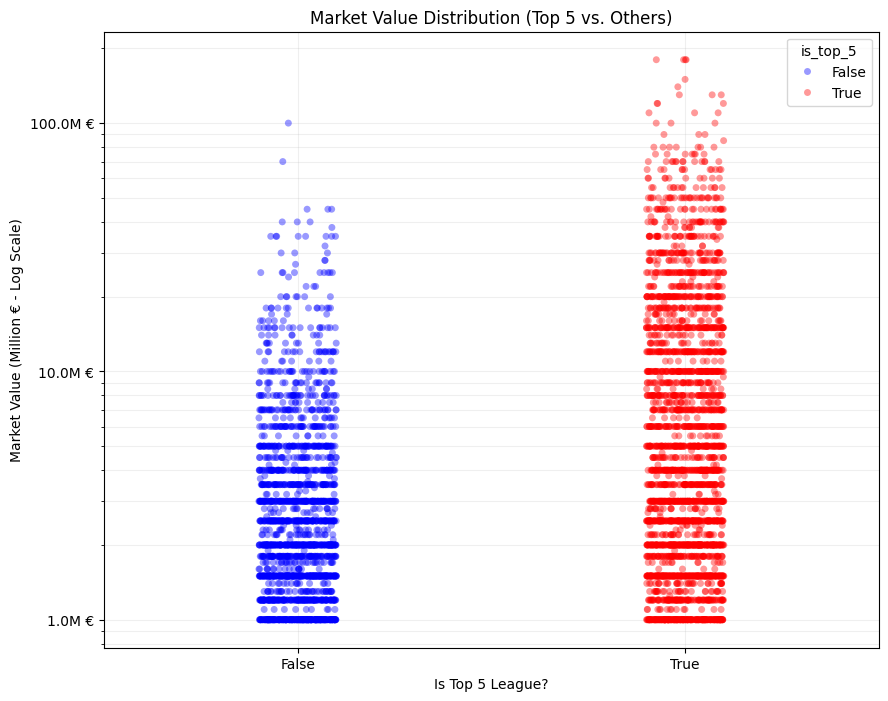

In [7]:
# Visualization: Market value distribution analysis using a logarithmic scale to compare Top 5 leagues against others
plt.figure(figsize=(10, 8))

sns.stripplot(
    data=players,
    x='is_top_5',
    y='market_value_in_eur',
    palette={True: 'red', False: 'blue'},
    hue='is_top_5',
    jitter=True,
    alpha=0.4
)

plt.yscale('log')
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_millions))
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.title('Market Value Distribution (Top 5 vs. Others)')
plt.xlabel('Is Top 5 League?')
plt.ylabel('Market Value (Million € - Log Scale)')
plt.show()

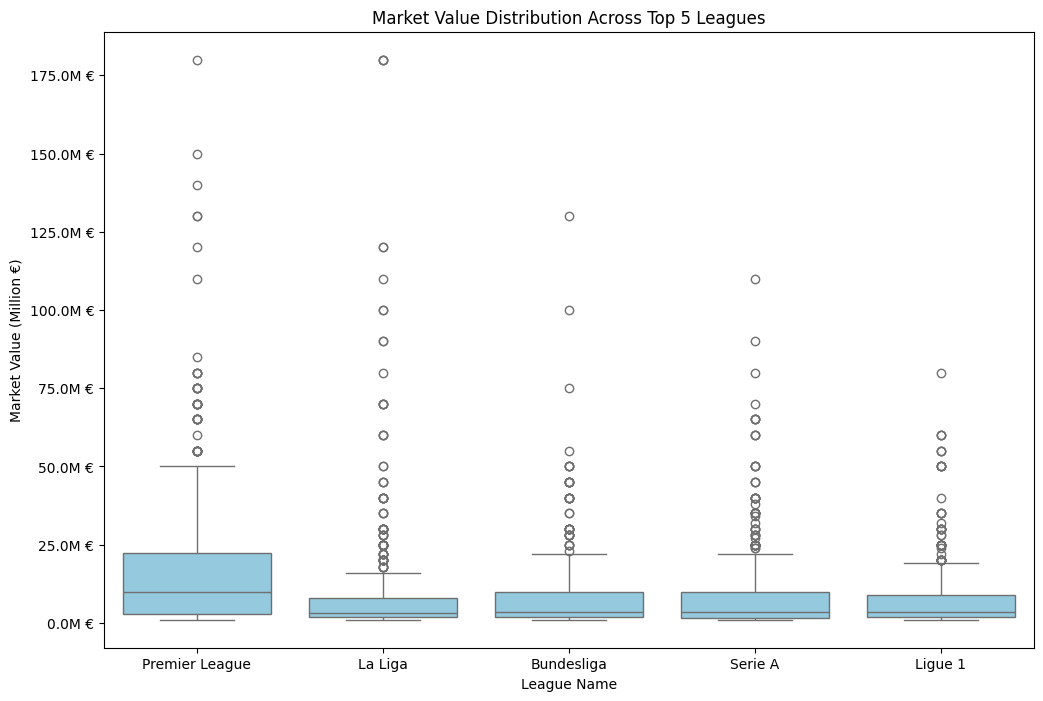

league_name
Premier League    1.716496e+07
La Liga           9.073182e+06
Serie A           8.379018e+06
Bundesliga        8.350206e+06
Ligue 1           7.564315e+06
Name: market_value_in_eur, dtype: float64


In [8]:
# Comparative Analysis: Distribution and mean of player market values across the Top 5 European leagues
top_5_players['league_name'] = top_5_players['current_club_domestic_competition_id'].map(league_names)

plt.figure(figsize=(12, 8))

sns.boxplot(
    data=top_5_players,
    x='league_name',
    y='market_value_in_eur',
    color='skyblue',  
    order=['Premier League', 'La Liga', 'Bundesliga', 'Serie A', 'Ligue 1']
)

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_millions))

plt.title('Market Value Distribution Across Top 5 Leagues')
plt.xlabel('League Name')
plt.ylabel('Market Value (Million €)')
plt.show()

# Display mean market values per league ranked in descending order
print(top_5_players.groupby('league_name')['market_value_in_eur'].mean().sort_values(ascending=False))

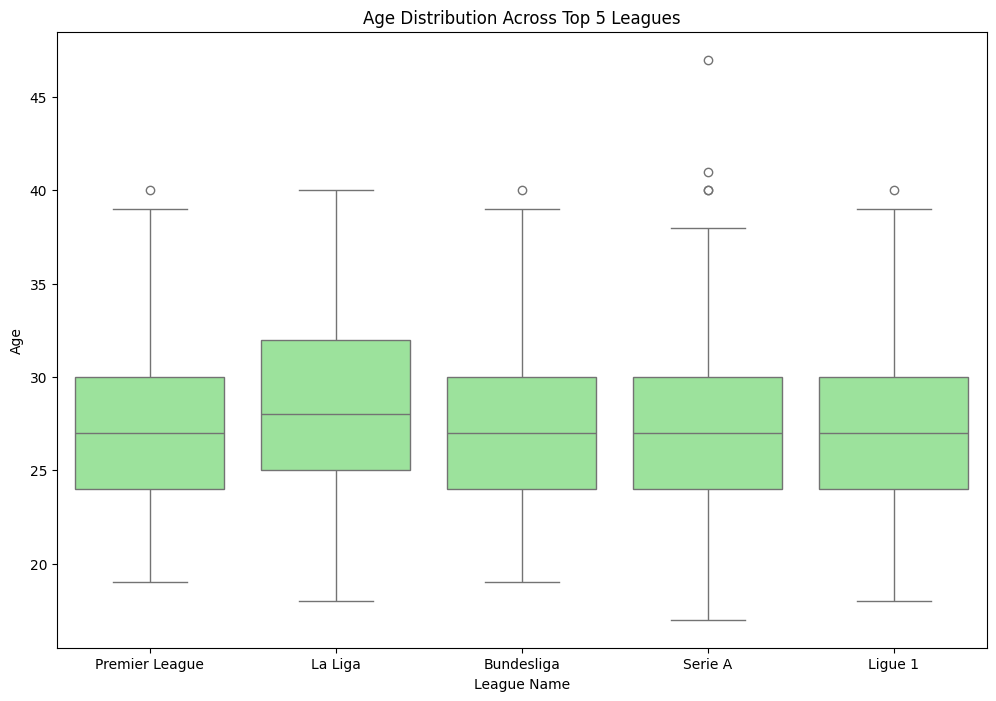

league_name
Premier League    27.132514
Bundesliga        27.156379
Ligue 1           27.377016
Serie A           27.385417
La Liga           28.580303
Name: age, dtype: float64


In [9]:
# Demographic Analysis: Visualizing and comparing the age distribution of players across the Top 5 European leagues
plt.figure(figsize=(12, 8))

sns.boxplot(
    data=top_5_players,
    x='league_name',
    y='age',
    color='lightgreen',  
    order=['Premier League', 'La Liga', 'Bundesliga', 'Serie A', 'Ligue 1']
)

plt.title('Age Distribution Across Top 5 Leagues')
plt.xlabel('League Name')
plt.ylabel('Age')
plt.show()

# Display mean age per league to identify the youngest and oldest competitions
print(top_5_players.groupby('league_name')['age'].mean().sort_values())

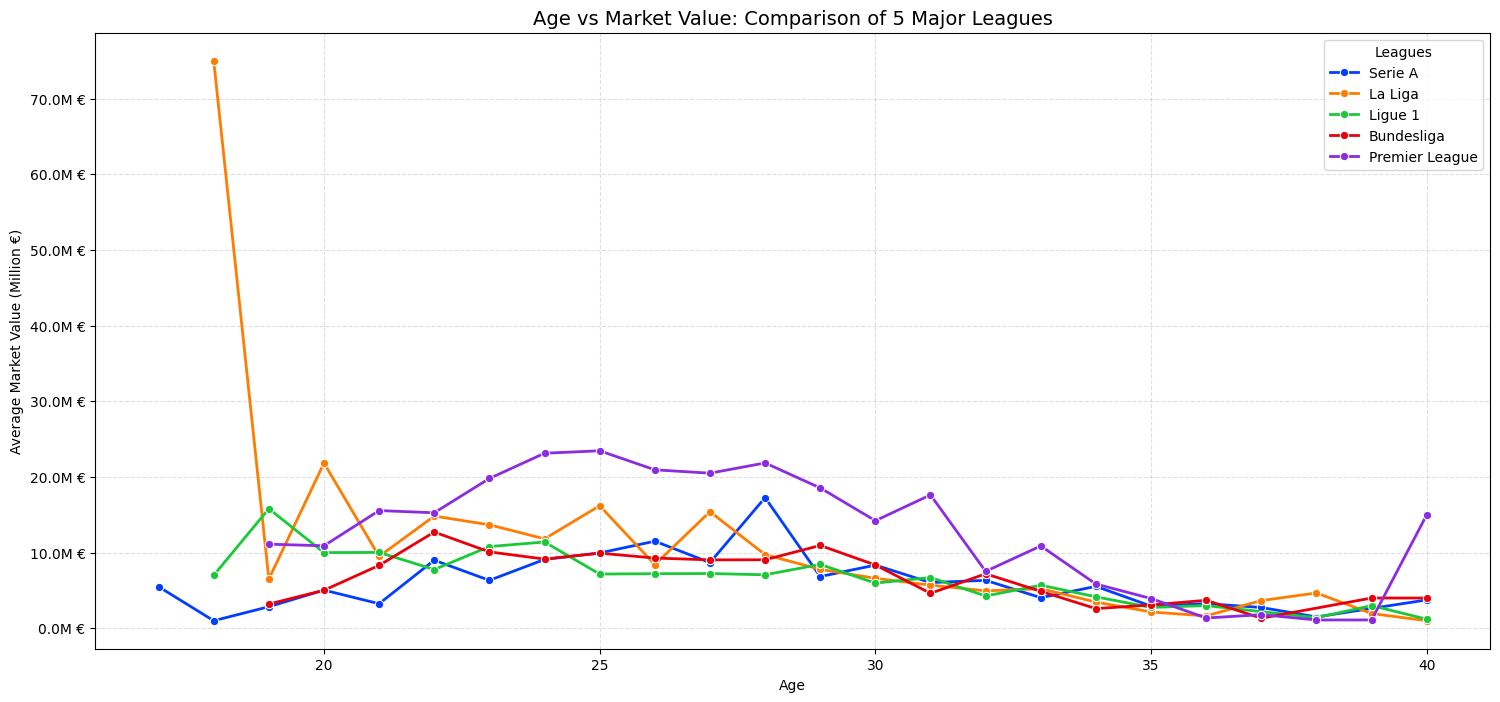

In [10]:
# Trend Analysis: Comparing the relationship between age (16-40) and average market value specifically across the Top 5 European leagues
df_age = players[(players['age'] >= 16) & (players['age'] <= 40)].copy()

df_age['league_name'] = df_age['current_club_domestic_competition_id'].map(league_names)
df_age['league_group'] = df_age['is_top_5'].map({True: 'Top 5 Leagues', False: 'Other Leagues'})

fig, ax1 = plt.subplots(1, figsize=(18, 8))

# Aggregate data to find the mean market value per age group for each major league
top_5_data = df_age[df_age['is_top_5'] == True].groupby(['age', 'league_name'])['market_value_in_eur'].mean().reset_index()

sns.lineplot(
    data=top_5_data,
    x='age',
    y='market_value_in_eur',
    hue='league_name',
    marker='o',
    ax=ax1,
    linewidth=2,
    palette='bright'
)

ax1.set_title('Age vs Market Value: Comparison of 5 Major Leagues', fontsize=14)
ax1.set_xlabel('Age')
ax1.set_ylabel('Average Market Value (Million €)')
ax1.yaxis.set_major_formatter(FuncFormatter(format_millions))
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(title='Leagues')

plt.show()

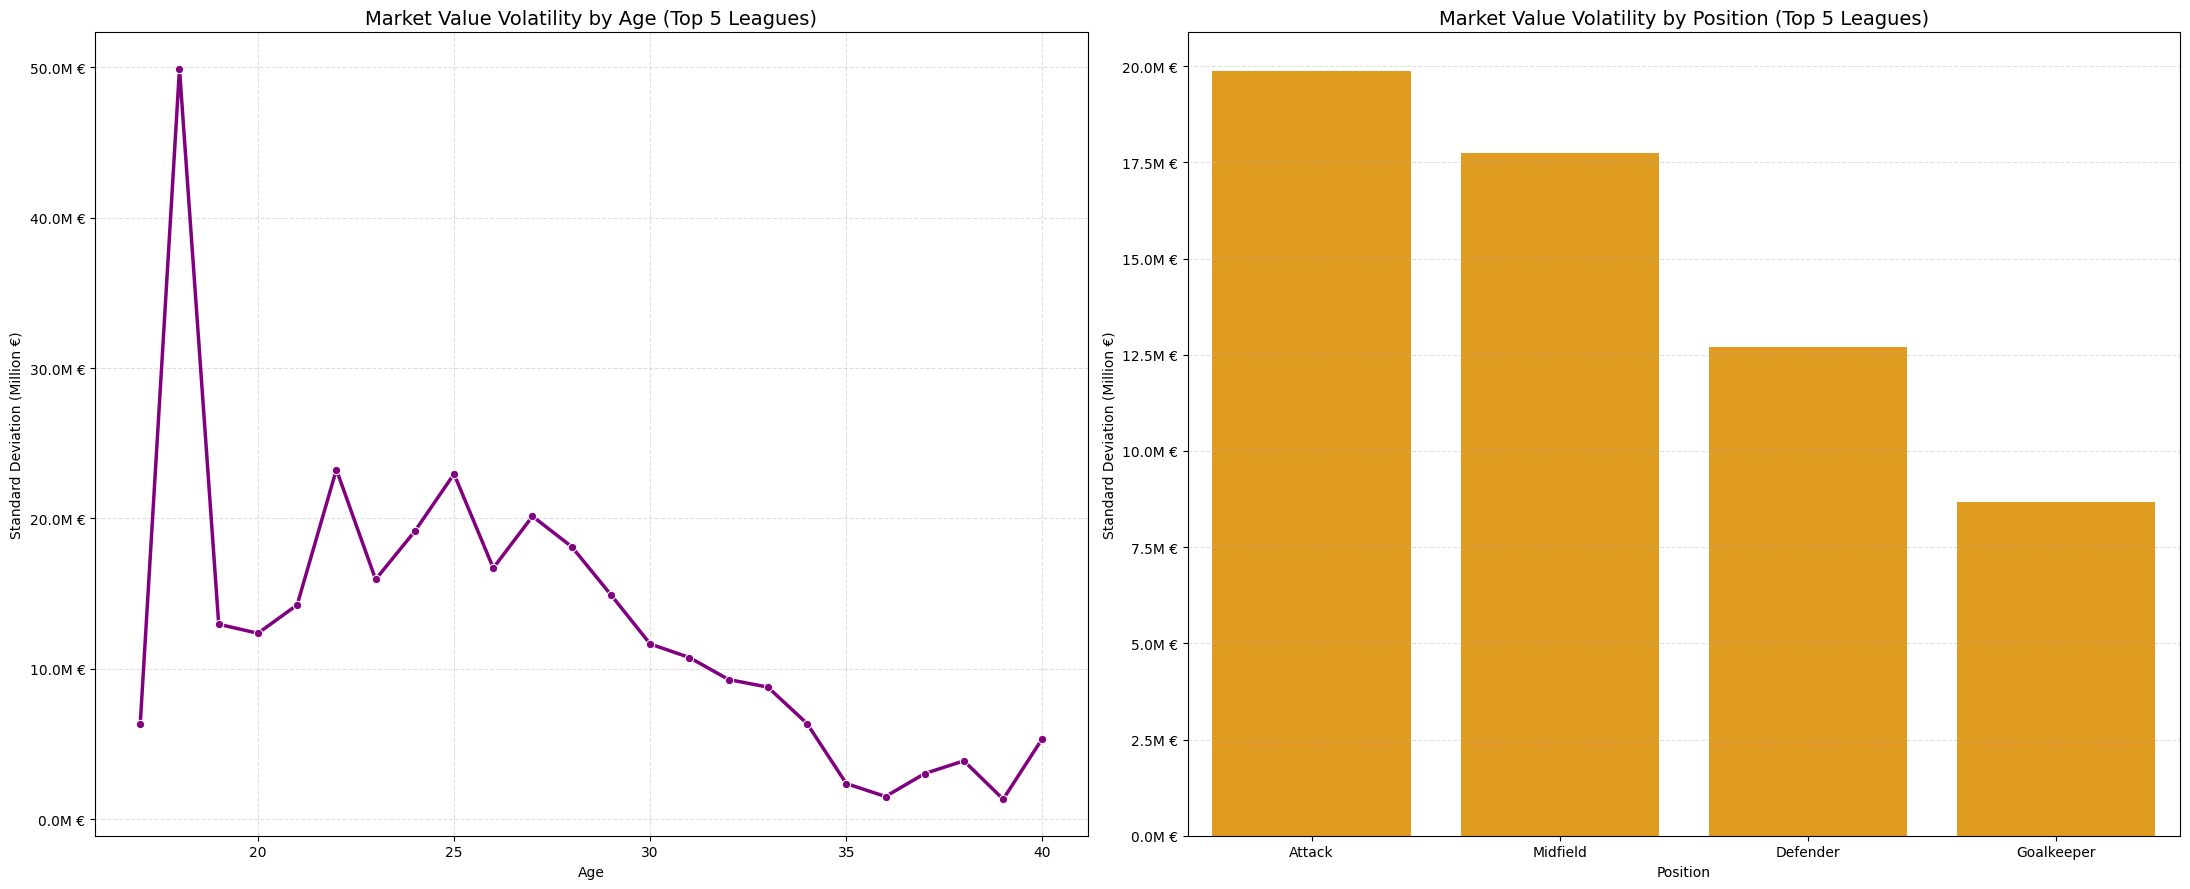

In [11]:
# Volatility Analysis: Measuring market value variation (Standard Deviation) across different ages and playing positions within the Top 5 leagues
top_5_only = players[players['is_top_5'] == True].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

# Plot 1: Standard Deviation by Age to identify at which age player values fluctuate the most
age_std = top_5_only.groupby('age')['market_value_in_eur'].std().reset_index()

sns.lineplot(
    data=age_std,
    x='age',
    y='market_value_in_eur',
    marker='o',
    ax=ax1,
    color='purple',
    linewidth=2.5
)

ax1.set_title('Market Value Volatility by Age (Top 5 Leagues)', fontsize=14)
ax1.set_xlabel('Age')
ax1.set_ylabel('Standard Deviation (Million €)')
ax1.yaxis.set_major_formatter(FuncFormatter(format_millions))
ax1.grid(True, linestyle='--', alpha=0.4)

# Plot 2: Standard Deviation by Position to visualize value gaps within specific roles
pos_std = top_5_only.groupby('position')['market_value_in_eur'].std().sort_values(ascending=False).reset_index()

sns.barplot(
    data=pos_std,
    x='position',
    y='market_value_in_eur',
    ax=ax2,
    color='orange'
)

ax2.set_title('Market Value Volatility by Position (Top 5 Leagues)', fontsize=14)
ax2.set_xlabel('Position')
ax2.set_ylabel('Standard Deviation (Million €)')
ax2.yaxis.set_major_formatter(FuncFormatter(format_millions))
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

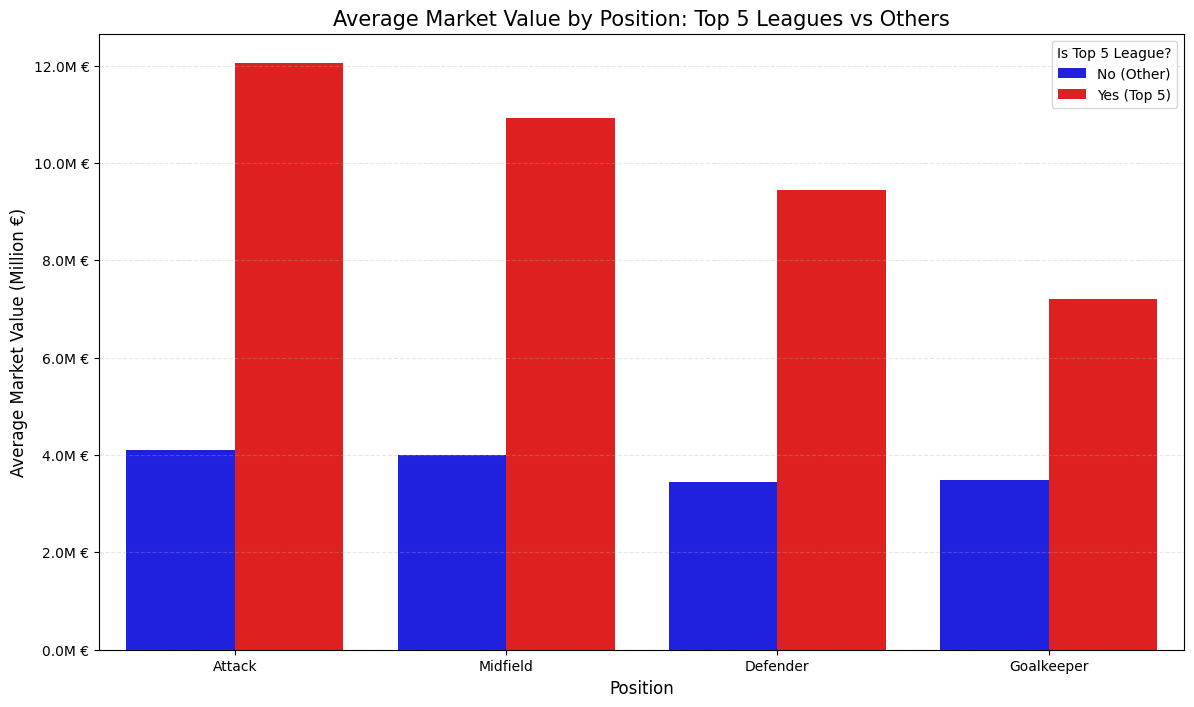

In [12]:
# Positional Analysis: Comparing average market values across different playing positions between Top 5 leagues and other competitions
plt.figure(figsize=(14, 8))

# Order positions by mean market value for a cleaner visualization
order = players.groupby('position')['market_value_in_eur'].mean().sort_values(ascending=False).index

sns.barplot(
    data=players,
    x='position',
    y='market_value_in_eur',
    hue='is_top_5',
    palette={True: 'red', False: 'blue'},
    order=order,
    errorbar=None
)

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_millions))
plt.title('Average Market Value by Position: Top 5 Leagues vs Others', fontsize=15)
plt.xlabel('Position', fontsize=12)
plt.ylabel('Average Market Value (Million €)', fontsize=12)
plt.legend(title='Is Top 5 League?', labels=['No (Other)', 'Yes (Top 5)'])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

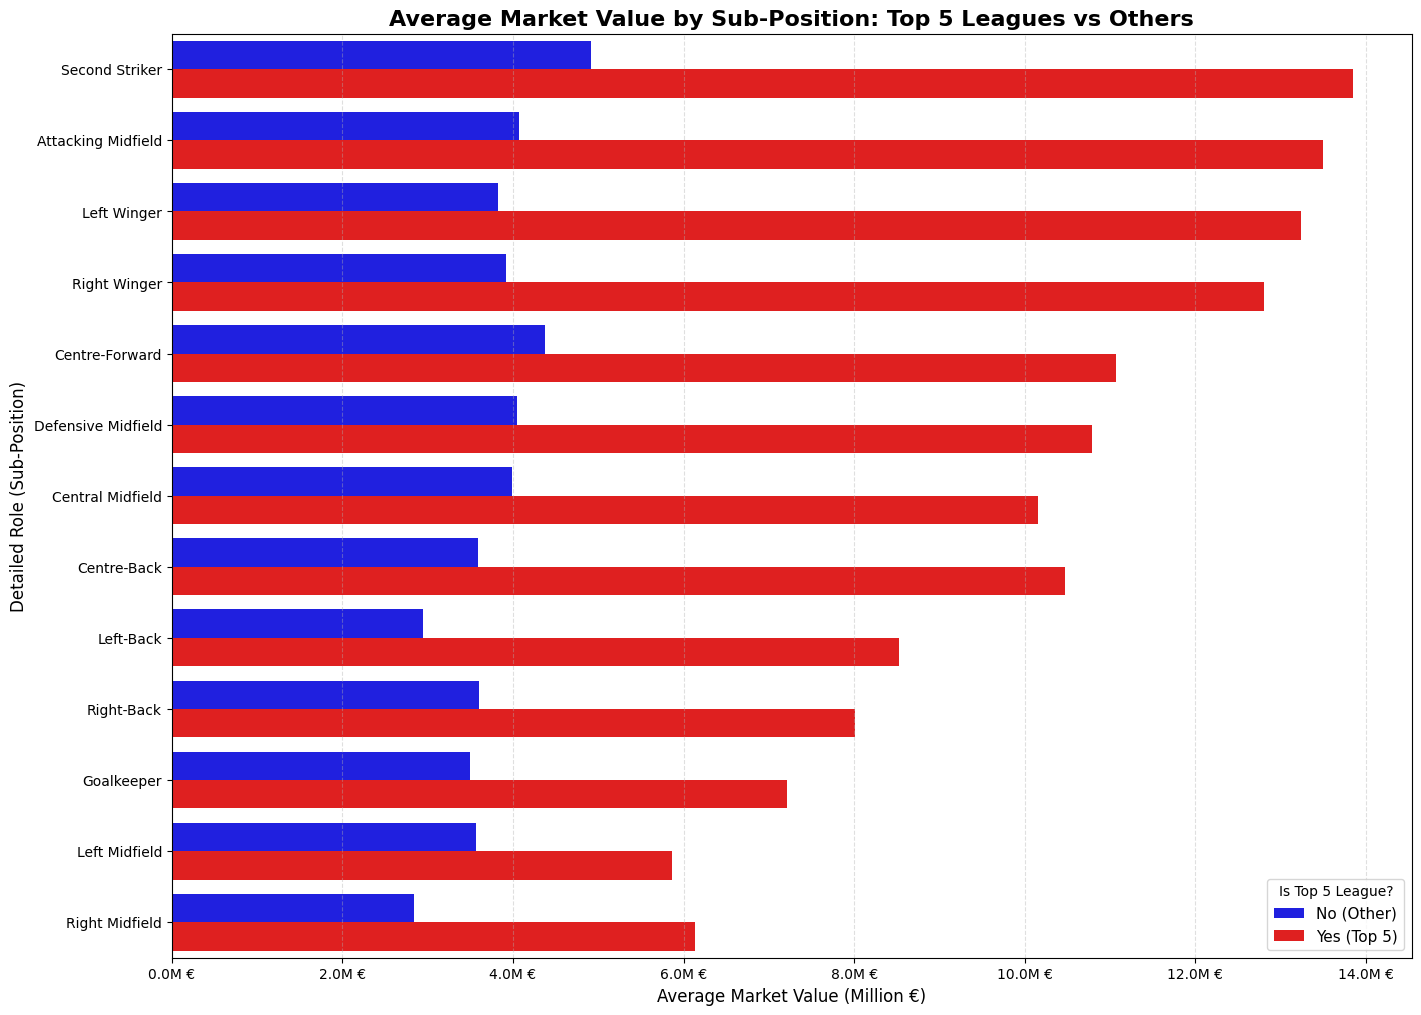

In [13]:
# Granular Analysis: Comparing average market values across specific sub-positions between Top 5 leagues and other competitions
order_sub = players.groupby('sub_position')['market_value_in_eur'].mean().sort_values(ascending=False).index

plt.figure(figsize=(16, 12))

ax = sns.barplot(
    data=players,
    y='sub_position',
    x='market_value_in_eur',
    hue='is_top_5',
    palette={True: 'red', False: 'blue'},
    order=order_sub,
    errorbar=None
)

plt.gca().xaxis.set_major_formatter(FuncFormatter(format_millions))
plt.title('Average Market Value by Sub-Position: Top 5 Leagues vs Others', fontsize=16, weight='bold')
plt.ylabel('Detailed Role (Sub-Position)', fontsize=12)
plt.xlabel('Average Market Value (Million €)', fontsize=12)

plt.legend(title='Is Top 5 League?', labels=['No (Other)', 'Yes (Top 5)'], loc='lower right', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

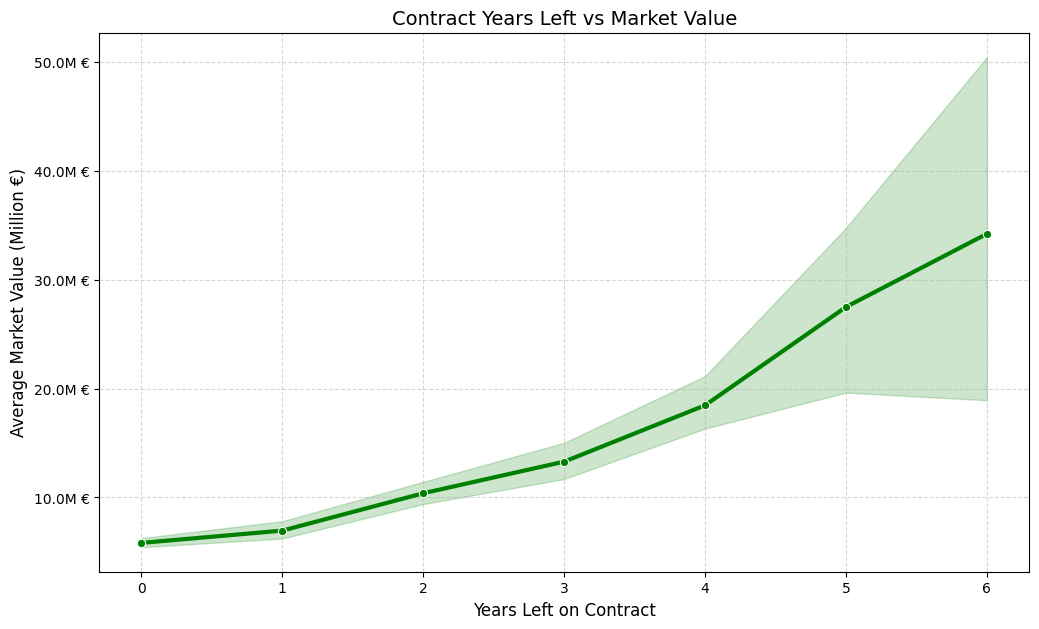

years_left
0     5.83M €
1     6.96M €
2    10.39M €
3    13.29M €
4    18.46M €
5    27.49M €
6    34.21M €
Name: market_value_in_eur, dtype: object


In [14]:
# Contract Analysis: Investigating the relationship between remaining contract duration and average market value
players['contract_expiration_date'] = pd.to_datetime(players['contract_expiration_date'])
players['years_left'] = (players['contract_expiration_date'].dt.year - 2026)

contract_df = players[(players['years_left'] >= 0) & (players['years_left'] <= 6)].copy()

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=contract_df,
    x='years_left',
    y='market_value_in_eur',
    marker='o',
    color='green',
    linewidth=3
)

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_millions))
plt.title('Contract Years Left vs Market Value', fontsize=14)
plt.xlabel('Years Left on Contract', fontsize=12)
plt.ylabel('Average Market Value (Million €)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Display numerical summary of average market value by contract longevity
print(contract_df.groupby('years_left')['market_value_in_eur'].mean().apply(lambda x: f"{x/1e6:.2f}M €"))

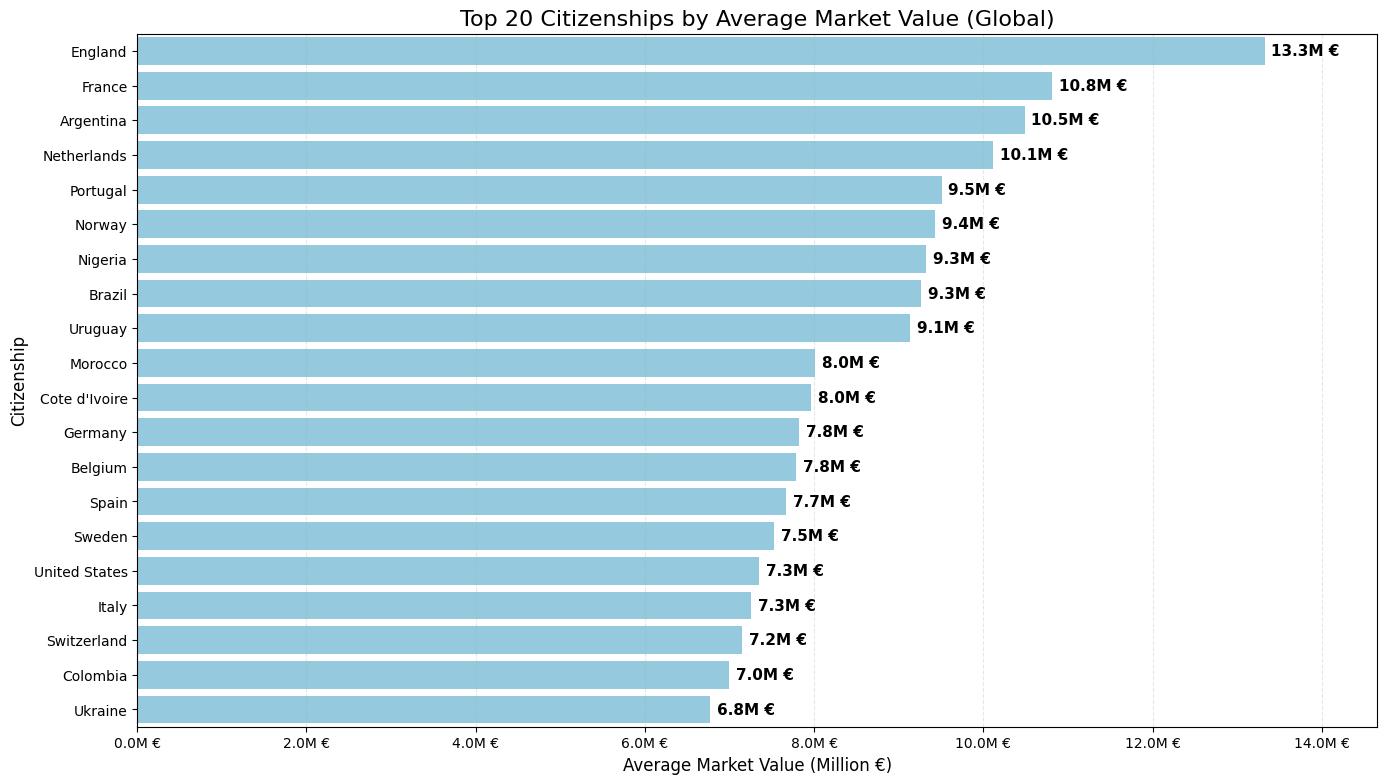

   country_of_citizenship     avg_value  player_count
0                 England  1.332435e+07           308
1                  France  1.081118e+07           340
2               Argentina  1.048732e+07           142
3             Netherlands  1.011141e+07           184
4                Portugal  9.506186e+06           194
5                  Norway  9.432836e+06            67
6                 Nigeria  9.317460e+06            63
7                  Brazil  9.262890e+06           353
8                 Uruguay  9.139344e+06            61
9                 Morocco  8.013889e+06            72
10          Cote d'Ivoire  7.965625e+06            64
11                Germany  7.825197e+06           254
12                Belgium  7.789041e+06           146
13                  Spain  7.664270e+06           459
14                 Sweden  7.528814e+06            59
15          United States  7.344262e+06            61
16                  Italy  7.258955e+06           268
17            Switzerland  7

In [15]:
# Geographic Analysis: Identifying the Top 20 nations with the highest average player market value (minimum 50 players per country)
country_stats = players.groupby('country_of_citizenship').agg(
    avg_value=('market_value_in_eur', 'mean'),
    player_count=('player_id', 'count')
).query('player_count >= 50').sort_values(by='avg_value', ascending=False)

top_20_countries = country_stats.head(20).reset_index()

plt.figure(figsize=(16, 9))

ax = sns.barplot(
    data=top_20_countries,
    x='avg_value',
    y='country_of_citizenship',
    color='skyblue'  
)

# Annotate bars
for container in ax.containers:
    labels = [f'{x/1e6:.1f}M €' for x in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontsize=11, color='black', weight='bold')

plt.gca().xaxis.set_major_formatter(FuncFormatter(format_millions))
plt.title('Top 20 Citizenships by Average Market Value (Global)', fontsize=16)
plt.xlabel('Average Market Value (Million €)', fontsize=12)
plt.ylabel('Citizenship', fontsize=12)

max_value = top_20_countries['avg_value'].max()
plt.xlim(0, max_value * 1.1)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

print(top_20_countries)

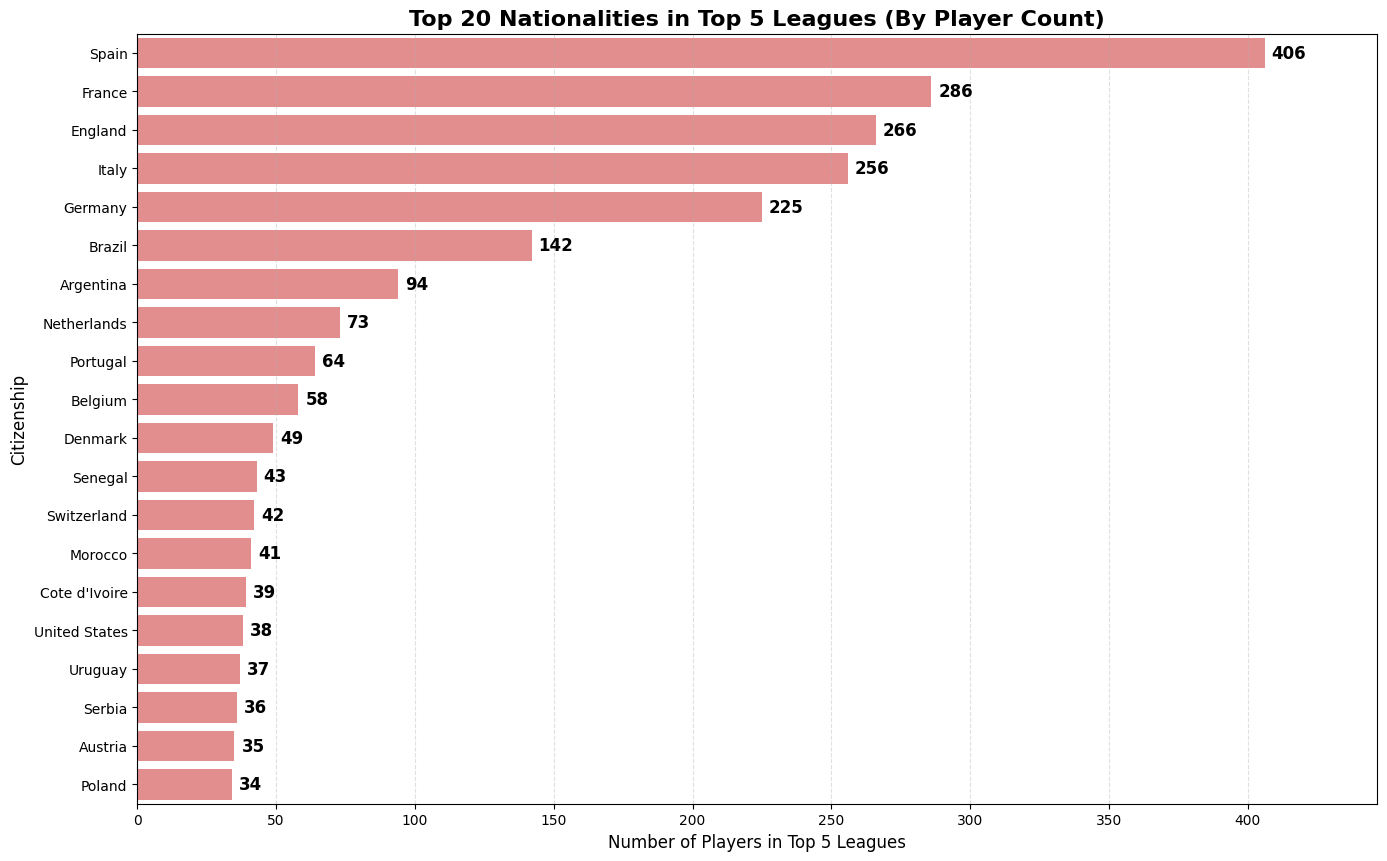

In [16]:
# Demographic Distribution: Ranking the Top 20 nationalities with the highest representation (player count) across the Top 5 European leagues
nationality_counts = top_5_players['country_of_citizenship'].value_counts().reset_index()
nationality_counts.columns = ['country_of_citizenship', 'player_count']
top_20_nationalities = nationality_counts.head(20)

plt.figure(figsize=(16, 10))
ax = sns.barplot(
    data=top_20_nationalities,
    x='player_count',
    y='country_of_citizenship',
    color='lightcoral'  
)

# Annotate each bar
for container in ax.containers:
    labels = [f"{int(x)}" for x in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontsize=12, color='black', weight='bold')

plt.title('Top 20 Nationalities in Top 5 Leagues (By Player Count)', fontsize=16, weight='bold')
plt.xlabel('Number of Players in Top 5 Leagues', fontsize=12)
plt.ylabel('Citizenship', fontsize=12)
plt.xlim(0, top_20_nationalities['player_count'].max() * 1.1)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

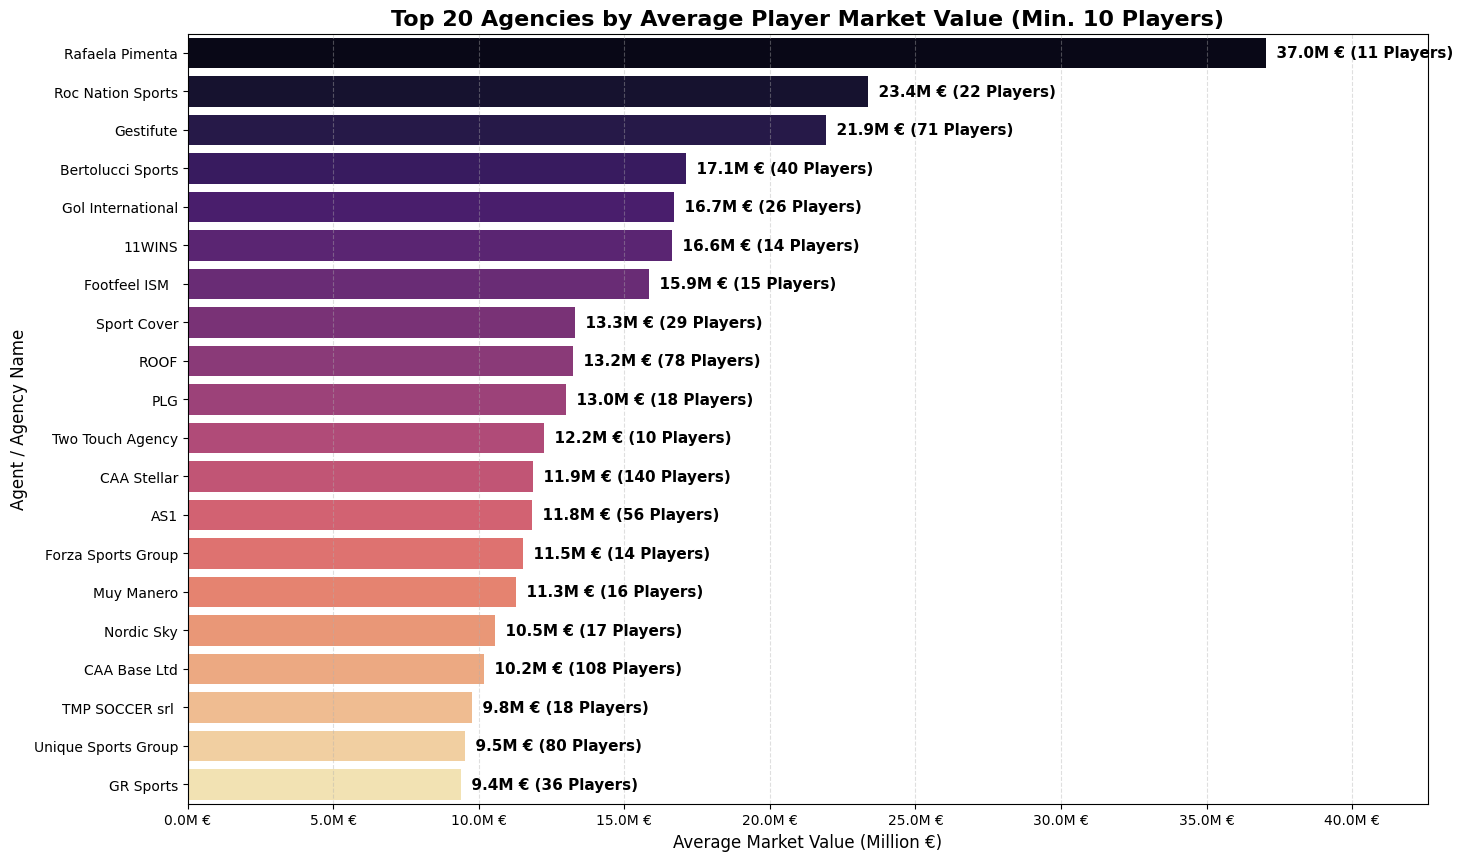

In [17]:
# Agency Analysis: Ranking the Top 20 football agencies based on the average market value of their clients (minimum 10 players)
agent_stats = players.groupby('agent_name').agg(
    avg_value=('market_value_in_eur', 'mean'),
    player_count=('player_id', 'count')
).query('player_count >= 10').sort_values(by='avg_value', ascending=False)

top_20_agents = agent_stats.head(20).reset_index()

plt.figure(figsize=(16, 10))

# Visualizing the top agencies using a horizontal bar plot
ax = sns.barplot(
    data=top_20_agents,
    x='avg_value',
    y='agent_name',
    hue='agent_name',
    palette='magma',
    legend=False
)

# Annotating bars with average value in millions and the total player count for each agency
for i, row in top_20_agents.iterrows():
    text_label = f"  {row['avg_value']/1e6:.1f}M € ({int(row['player_count'])} Players)"
    ax.text(row['avg_value'], i, text_label, va='center', fontsize=11, color='black', weight='bold')

plt.gca().xaxis.set_major_formatter(FuncFormatter(format_millions))
plt.title('Top 20 Agencies by Average Player Market Value (Min. 10 Players)', fontsize=16, weight='bold')
plt.xlabel('Average Market Value (Million €)', fontsize=12)
plt.ylabel('Agent / Agency Name', fontsize=12)

# Adjust x-axis limit to accommodate descriptive labels
plt.xlim(0, top_20_agents['avg_value'].max() * 1.15)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

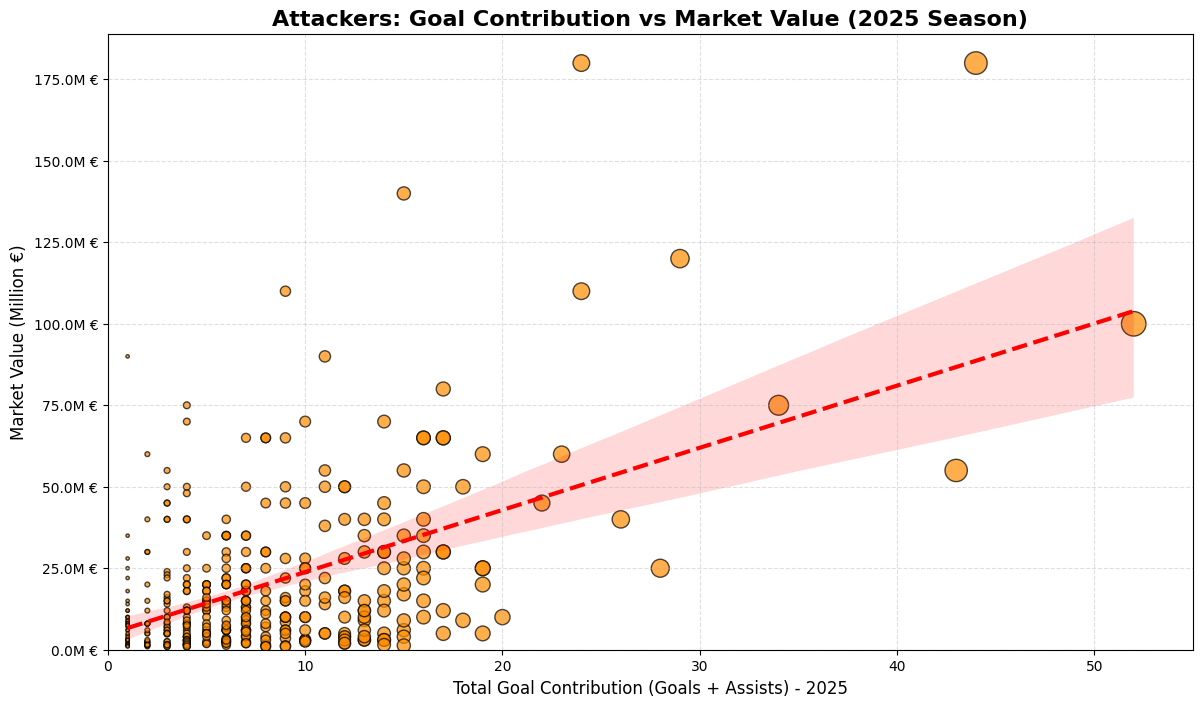

Correlation (Attackers - 2025 Season): 0.51


In [18]:
# Performance Analysis: Evaluating the correlation between goal contributions (Goals + Assists) and market value for attackers in the 2025 season
games = pd.read_csv(os.path.join(path, "games.csv"), usecols=['game_id', 'season'])
app_with_season = pd.merge(appearances, games, on='game_id', how='left')

target_season = 2025
target_season_apps = app_with_season[app_with_season['season'] == target_season]

player_season_stats = target_season_apps.groupby('player_id').agg(
    season_goals=('goals', 'sum'),
    season_assists=('assists', 'sum')
).reset_index()

player_season_stats['season_contribution'] = player_season_stats['season_goals'] + player_season_stats['season_assists']
player_season_stats = player_season_stats[player_season_stats['season_contribution'] > 0]

merged_season_df = pd.merge(top_5_players, player_season_stats, on='player_id', how='inner')
attackers_df = merged_season_df[merged_season_df['position'] == 'Attack'].copy()

plt.figure(figsize=(14, 8))

ax = sns.regplot(
    data=attackers_df,
    x='season_contribution',
    y='market_value_in_eur',
    scatter_kws={'alpha': 0.7, 's': attackers_df['season_contribution'] * 6, 'color': 'darkorange', 'edgecolor': 'black'},
    line_kws={'color': 'red', 'linewidth': 3, 'linestyle': '--'}
)

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_millions))
plt.title(f'Attackers: Goal Contribution vs Market Value ({target_season} Season)', fontsize=16, weight='bold')
plt.xlabel(f'Total Goal Contribution (Goals + Assists) - {target_season}', fontsize=12)
plt.ylabel('Market Value (Million €)', fontsize=12)

plt.xlim(0, attackers_df['season_contribution'].max() + 3)
plt.ylim(0, attackers_df['market_value_in_eur'].max() * 1.05)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

corr_attack = attackers_df['season_contribution'].corr(attackers_df['market_value_in_eur'])
print(f"Correlation (Attackers - {target_season} Season): {corr_attack:.2f}")

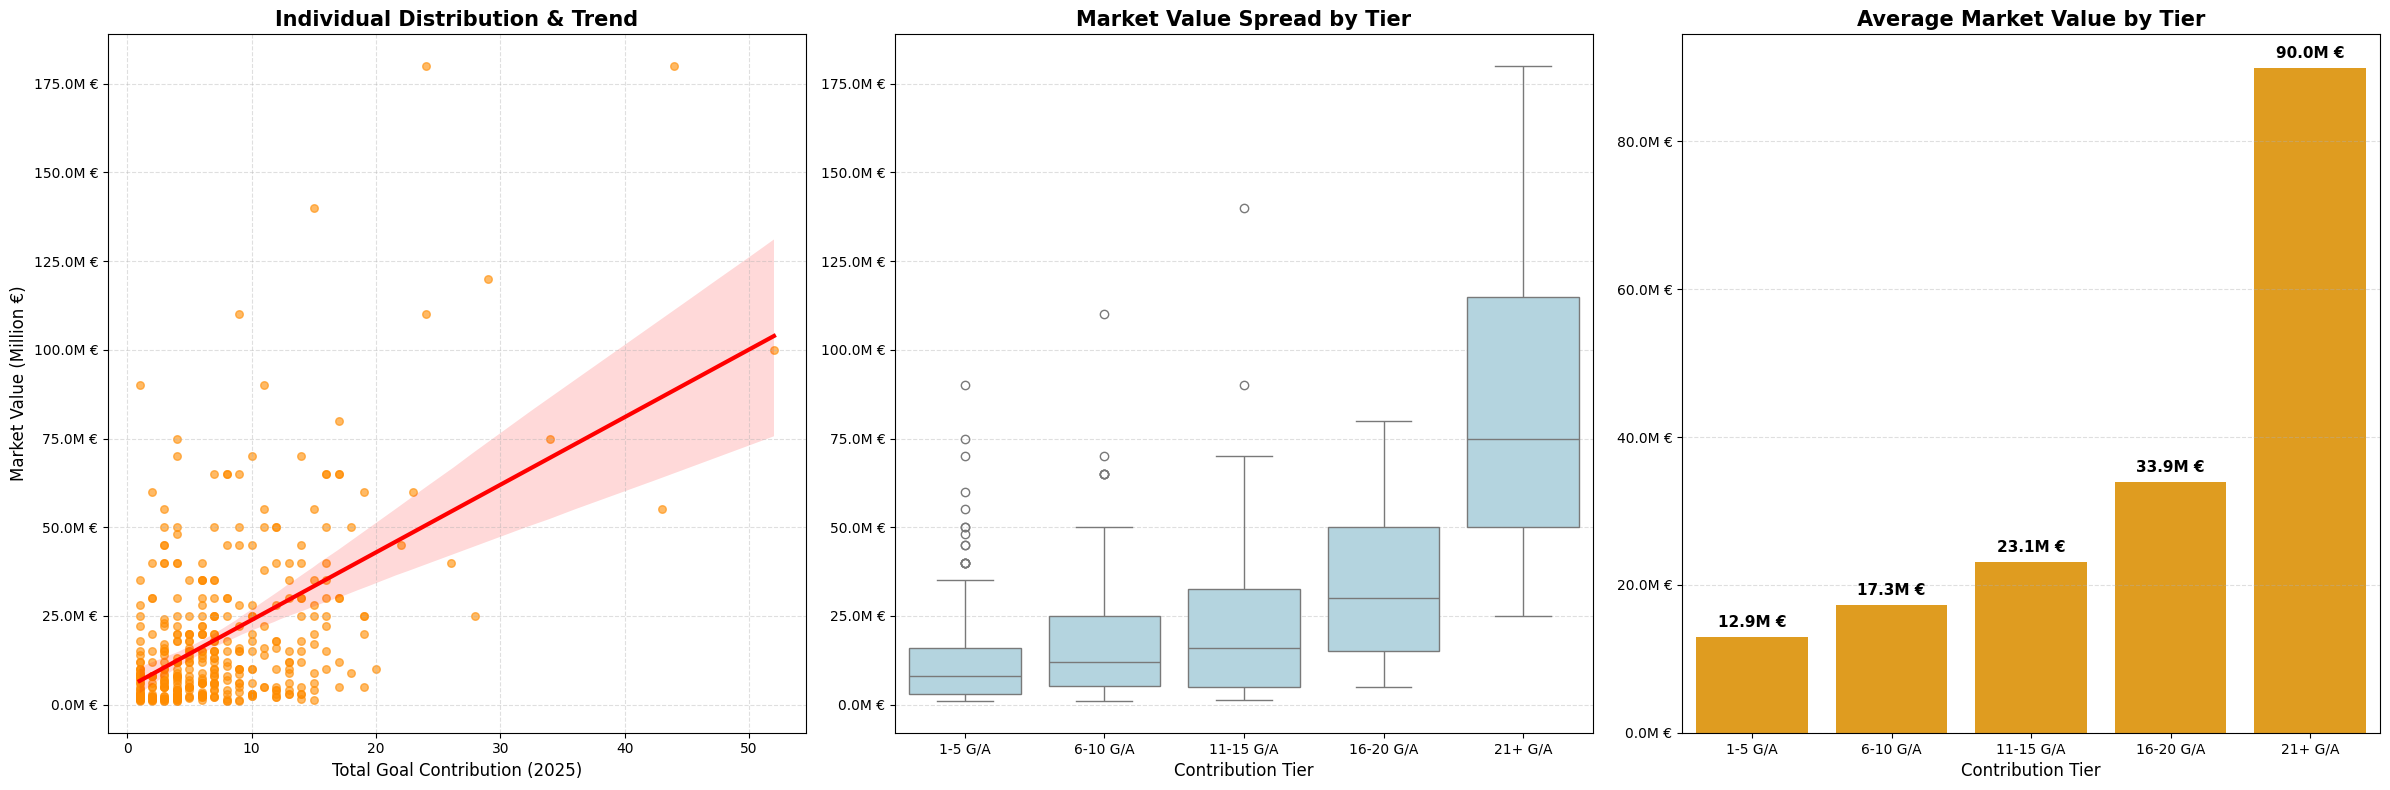

In [19]:
# Tier Analysis: Categorizing goal contributions into performance tiers and visualizing their impact on market value through trend, spread, and average analysis
bins = [0, 5, 10, 15, 20, 100]
labels = ['1-5 G/A', '6-10 G/A', '11-15 G/A', '16-20 G/A', '21+ G/A']
attackers_df['contribution_tier'] = pd.cut(attackers_df['season_contribution'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Subplot 1: Regression plot showing individual player distribution and overall trend
sns.regplot(
    data=attackers_df,
    x='season_contribution',
    y='market_value_in_eur',
    scatter_kws={'alpha': 0.6, 's': 30, 'color': 'darkorange'},
    line_kws={'color': 'red', 'linewidth': 3},
    ax=axes[0]
)
axes[0].set_title('Individual Distribution & Trend', fontsize=15, weight='bold')
axes[0].set_xlabel('Total Goal Contribution (2025)', fontsize=12)
axes[0].set_ylabel('Market Value (Million €)', fontsize=12)
axes[0].yaxis.set_major_formatter(FuncFormatter(format_millions))
axes[0].grid(True, linestyle='--', alpha=0.4)

# Subplot 2: Box plot showing the market value spread and outliers for each contribution tier
sns.boxplot(
    data=attackers_df,
    x='contribution_tier',
    y='market_value_in_eur',
    color='lightblue',  
    ax=axes[1]
)
axes[1].set_title('Market Value Spread by Tier', fontsize=15, weight='bold')
axes[1].set_xlabel('Contribution Tier', fontsize=12)
axes[1].set_ylabel('')
axes[1].yaxis.set_major_formatter(FuncFormatter(format_millions))
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# Subplot 3: Bar plot comparing average market values across tiers with data labels
sns.barplot(
    data=attackers_df,
    x='contribution_tier',
    y='market_value_in_eur',
    color='orange',
    errorbar=None,
    ax=axes[2]
)
axes[2].set_title('Average Market Value by Tier', fontsize=15, weight='bold')
axes[2].set_xlabel('Contribution Tier', fontsize=12)
axes[2].set_ylabel('')
axes[2].yaxis.set_major_formatter(FuncFormatter(format_millions))
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

# Annotate bars with average value labels
for container in axes[2].containers:
    axes[2].bar_label(container, fmt=lambda x: f'{x/1e6:.1f}M €', padding=5, weight='bold', fontsize=11)

plt.tight_layout()
plt.show()

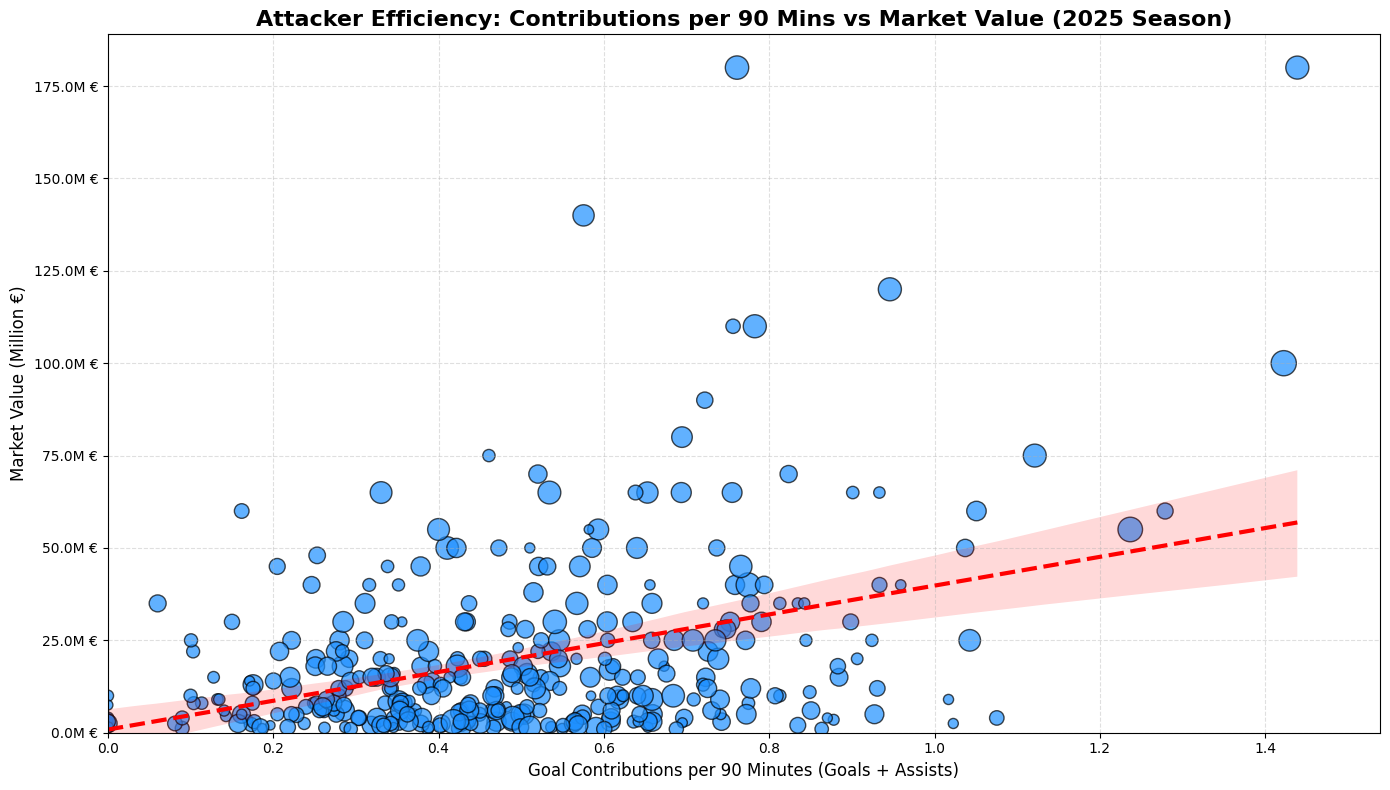

Correlation (Efficiency per 90 vs Market Value): 0.40


In [20]:
# Efficiency Analysis: Examining the relationship between normalized goal contributions per 90 minutes and market value for attackers with significant playing time (min. 450 minutes)
player_eff = target_season_apps.groupby('player_id').agg(
    season_goals=('goals', 'sum'),
    season_assists=('assists', 'sum'),
    season_minutes=('minutes_played', 'sum')
).reset_index()

player_eff['season_contribution'] = player_eff['season_goals'] + player_eff['season_assists']
player_eff = player_eff[player_eff['season_minutes'] >= 450]
player_eff['contribution_per_90'] = (player_eff['season_contribution'] / player_eff['season_minutes']) * 90

top_5_attackers = top_5_players[top_5_players['position'] == 'Attack']
efficiency_df = pd.merge(top_5_attackers, player_eff, on='player_id', how='inner')

plt.figure(figsize=(14, 8))

# Scatter size (s) is determined by total season minutes played
ax = sns.regplot(
    data=efficiency_df,
    x='contribution_per_90',
    y='market_value_in_eur',
    scatter_kws={'alpha': 0.7, 's': efficiency_df['season_minutes'] / 10, 'color': 'dodgerblue', 'edgecolor': 'black'},
    line_kws={'color': 'red', 'linewidth': 3, 'linestyle': '--'}
)

plt.gca().yaxis.set_major_formatter(FuncFormatter(format_millions))
plt.title(f'Attacker Efficiency: Contributions per 90 Mins vs Market Value ({target_season} Season)', fontsize=16, weight='bold')
plt.xlabel('Goal Contributions per 90 Minutes (Goals + Assists)', fontsize=12)
plt.ylabel('Market Value (Million €)', fontsize=12)

plt.xlim(0, efficiency_df['contribution_per_90'].max() + 0.1)
plt.ylim(0, efficiency_df['market_value_in_eur'].max() * 1.05)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

corr_eff = efficiency_df['contribution_per_90'].corr(efficiency_df['market_value_in_eur'])
print(f"Correlation (Efficiency per 90 vs Market Value): {corr_eff:.2f}")

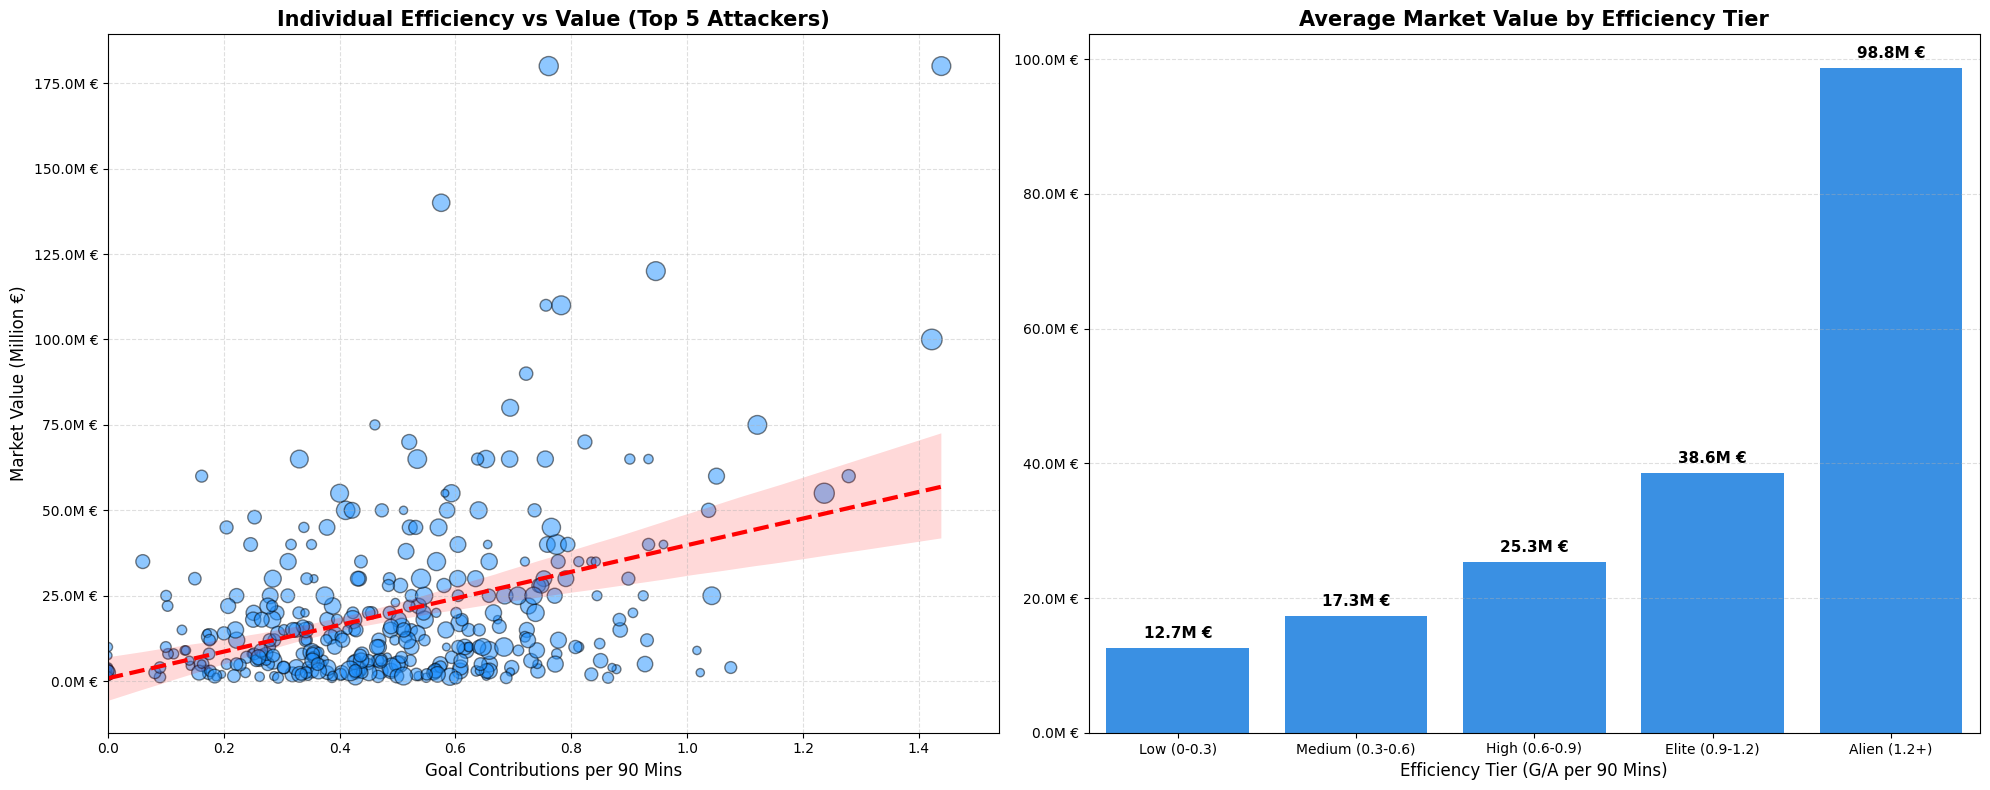

In [21]:
# Efficiency Segmentation: Categorizing attackers into performance tiers and comparing their average market values to identify the premium placed on elite efficiency
bins = [0, 0.3, 0.6, 0.9, 1.2, 10]
labels = ['Low (0-0.3)', 'Medium (0.3-0.6)', 'High (0.6-0.9)', 'Elite (0.9-1.2)', 'Alien (1.2+)']
efficiency_df['efficiency_tier'] = pd.cut(efficiency_df['contribution_per_90'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Regression analysis showing individual efficiency vs. market value
sns.regplot(
    data=efficiency_df,
    x='contribution_per_90',
    y='market_value_in_eur',
    scatter_kws={'alpha': 0.5, 's': efficiency_df['season_minutes'] / 15, 'color': 'dodgerblue', 'edgecolor': 'black'},
    line_kws={'color': 'red', 'linewidth': 3, 'linestyle': '--'},
    ax=axes[0]
)
axes[0].yaxis.set_major_formatter(FuncFormatter(format_millions))
axes[0].set_title('Individual Efficiency vs Value (Top 5 Attackers)', fontsize=15, weight='bold')
axes[0].set_xlabel('Goal Contributions per 90 Mins', fontsize=12)
axes[0].set_ylabel('Market Value (Million €)', fontsize=12)
axes[0].set_xlim(0, efficiency_df['contribution_per_90'].max() + 0.1)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Plot 2: Bar chart comparing average market values across defined efficiency tiers
sns.barplot(
    data=efficiency_df,
    x='efficiency_tier',
    y='market_value_in_eur',
    color='dodgerblue',  
    errorbar=None,
    ax=axes[1]
)
axes[1].yaxis.set_major_formatter(FuncFormatter(format_millions))
axes[1].set_title('Average Market Value by Efficiency Tier', fontsize=15, weight='bold')
axes[1].set_xlabel('Efficiency Tier (G/A per 90 Mins)', fontsize=12)
axes[1].set_ylabel('')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# Annotate bars with precise average market value labels
for container in axes[1].containers:
    axes[1].bar_label(container, fmt=lambda x: f'{x/1e6:.1f}M €', padding=5, weight='bold', fontsize=11)

plt.tight_layout()
plt.show()

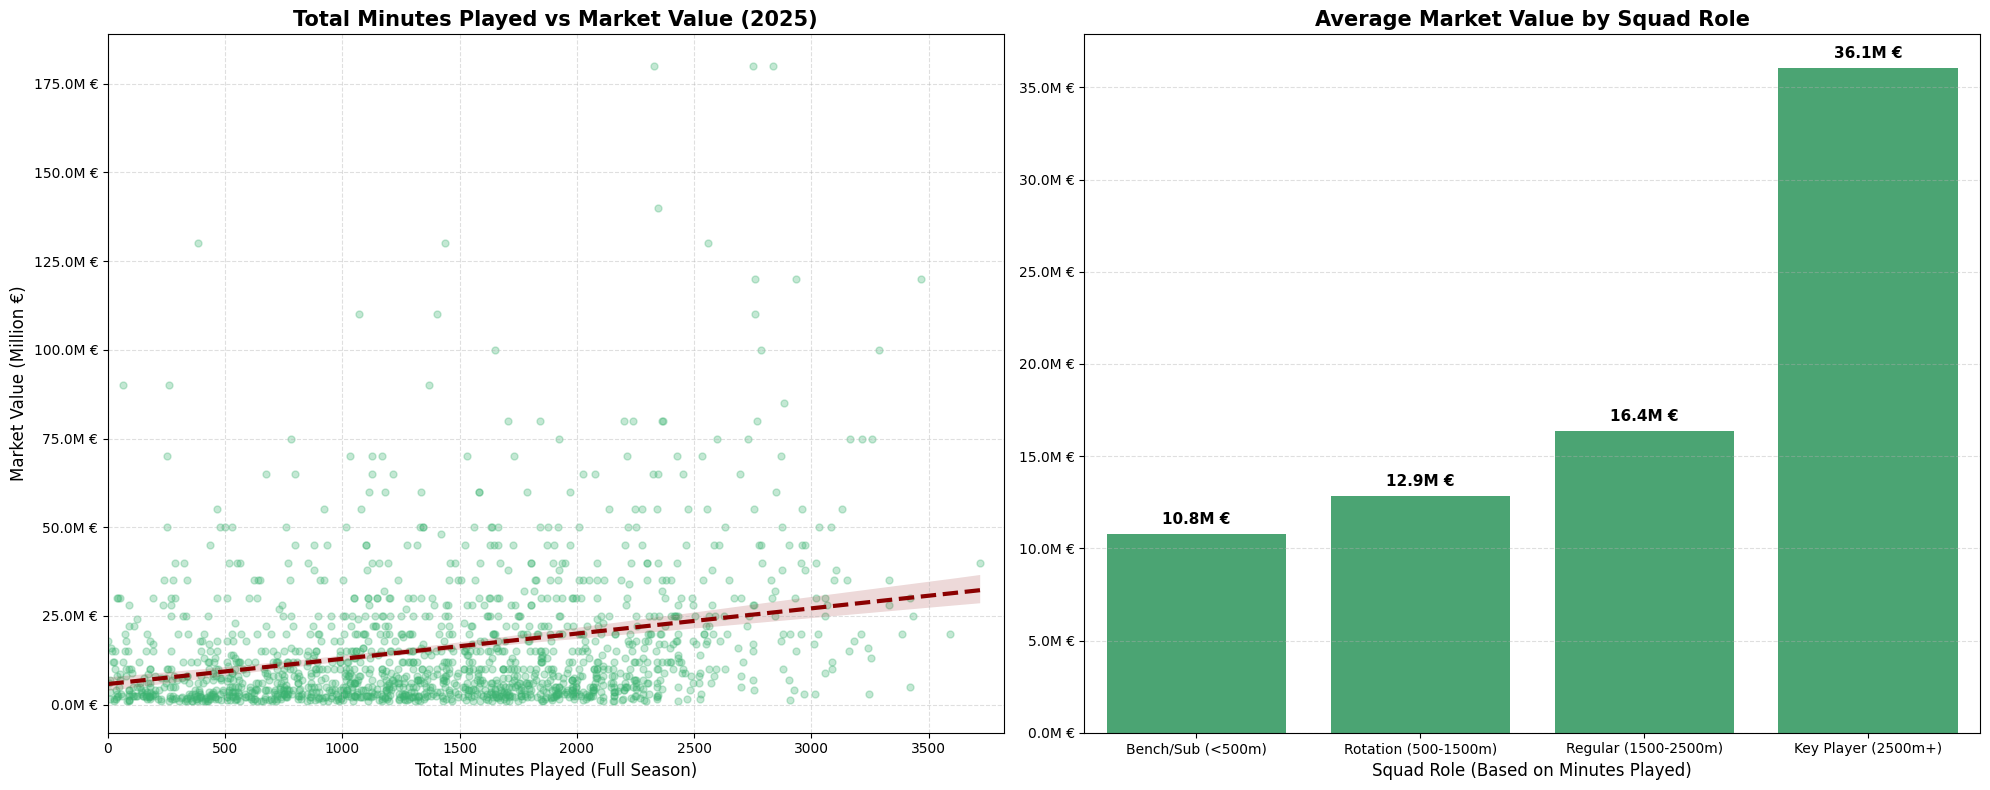

Correlation (Total Minutes vs Market Value): 0.28


In [22]:
# Squad Role Analysis: Evaluating the correlation between total minutes played and market value, categorizing players into squad roles based on their seasonal playtime
player_minutes = target_season_apps.groupby('player_id').agg(
    total_minutes=('minutes_played', 'sum')
).reset_index()

player_minutes = player_minutes[player_minutes['total_minutes'] > 0]

minutes_df = pd.merge(top_5_players, player_minutes, on='player_id', how='inner')

# Categorize players into squad roles based on total minutes played
bins = [0, 500, 1500, 2500, 5000]
labels = ['Bench/Sub (<500m)', 'Rotation (500-1500m)', 'Regular (1500-2500m)', 'Key Player (2500m+)']
minutes_df['playtime_tier'] = pd.cut(minutes_df['total_minutes'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Regression analysis showing individual distribution of playtime vs. market value
sns.regplot(
    data=minutes_df,
    x='total_minutes',
    y='market_value_in_eur',
    scatter_kws={'alpha': 0.3, 's': 25, 'color': 'mediumseagreen'},
    line_kws={'color': 'darkred', 'linewidth': 3, 'linestyle': '--'},
    ax=axes[0]
)
axes[0].yaxis.set_major_formatter(FuncFormatter(format_millions))
axes[0].set_title(f'Total Minutes Played vs Market Value ({target_season})', fontsize=15, weight='bold')
axes[0].set_xlabel('Total Minutes Played (Full Season)', fontsize=12)
axes[0].set_ylabel('Market Value (Million €)', fontsize=12)
axes[0].set_xlim(0, minutes_df['total_minutes'].max() + 100)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Plot 2: Average market value comparison across different squad roles
sns.barplot(
    data=minutes_df,
    x='playtime_tier',
    y='market_value_in_eur',
    color='mediumseagreen',  
    errorbar=None,
    ax=axes[1]
)
axes[1].yaxis.set_major_formatter(FuncFormatter(format_millions))
axes[1].set_title('Average Market Value by Squad Role', fontsize=15, weight='bold')
axes[1].set_xlabel('Squad Role (Based on Minutes Played)', fontsize=12)
axes[1].set_ylabel('')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# Annotate bars with average value labels
for container in axes[1].containers:
    axes[1].bar_label(container, fmt=lambda x: f'{x/1e6:.1f}M €', padding=5, weight='bold', fontsize=11)

plt.tight_layout()
plt.show()

corr_mins = minutes_df['total_minutes'].corr(minutes_df['market_value_in_eur'])
print(f"Correlation (Total Minutes vs Market Value): {corr_mins:.2f}")

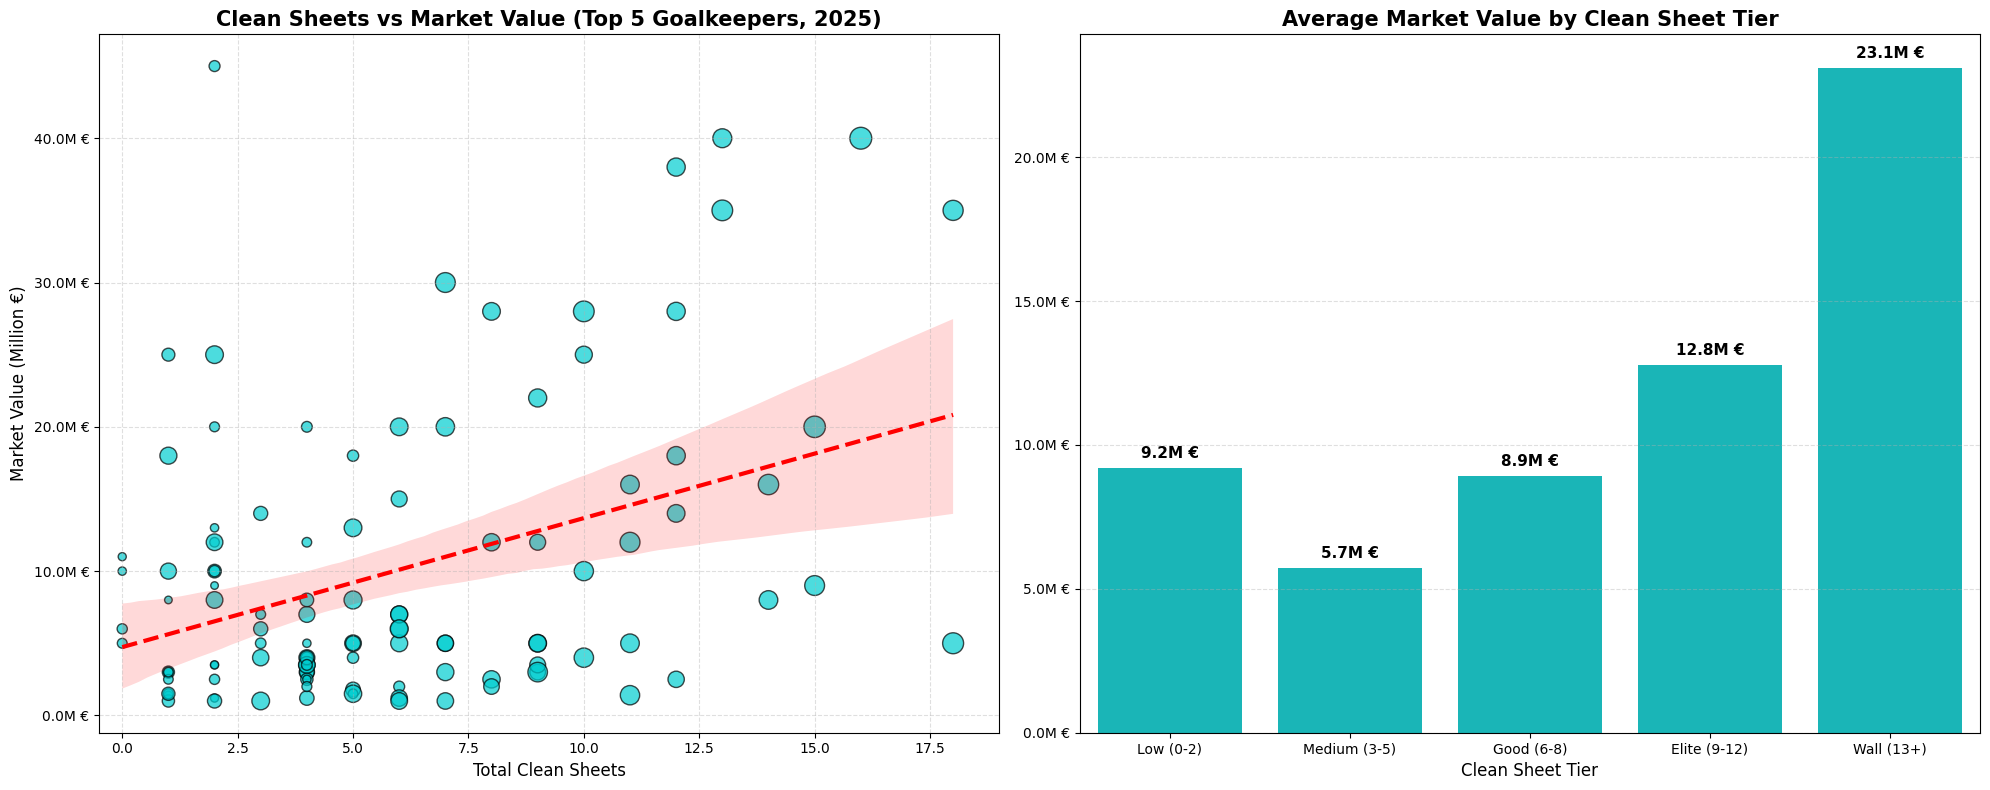

Correlation (Clean Sheets vs Market Value): 0.38


In [23]:
# Goalkeeper Analysis: Evaluating the impact of clean sheets on market value for Top 5 league goalkeepers, including performance tier segmentation
club_games = pd.read_csv(os.path.join(path, "club_games.csv"), usecols=['game_id', 'club_id', 'opponent_goals'])

# Merge appearance data with club match results to identify matches where the opponent scored zero goals
gk_apps = pd.merge(target_season_apps, club_games, left_on=['game_id', 'player_club_id'], right_on=['game_id', 'club_id'], how='inner')
gk_apps['is_clean_sheet'] = (gk_apps['opponent_goals'] == 0).astype(int)

# Aggregate clean sheet counts and total minutes, filtering for active goalkeepers with significant playtime
gk_stats = gk_apps.groupby('player_id').agg(
    total_clean_sheets=('is_clean_sheet', 'sum'),
    total_minutes=('minutes_played', 'sum')
).reset_index()

gk_stats = gk_stats[gk_stats['total_minutes'] >= 450]

top_5_gks = top_5_players[top_5_players['position'] == 'Goalkeeper']
gk_df = pd.merge(top_5_gks, gk_stats, on='player_id', how='inner')

# Segment goalkeepers into performance tiers based on clean sheet totals
bins = [-1, 2, 5, 8, 12, 50]
labels = ['Low (0-2)', 'Medium (3-5)', 'Good (6-8)', 'Elite (9-12)', 'Wall (13+)']
gk_df['clean_sheet_tier'] = pd.cut(gk_df['total_clean_sheets'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Regression analysis of clean sheets vs. market value
sns.regplot(
    data=gk_df,
    x='total_clean_sheets',
    y='market_value_in_eur',
    scatter_kws={'alpha': 0.7, 's': gk_df['total_minutes'] / 15, 'color': 'darkturquoise', 'edgecolor': 'black'},
    line_kws={'color': 'red', 'linewidth': 3, 'linestyle': '--'},
    ax=axes[0]
)
axes[0].yaxis.set_major_formatter(FuncFormatter(format_millions))
axes[0].set_title(f'Clean Sheets vs Market Value (Top 5 Goalkeepers, {target_season})', fontsize=15, weight='bold')
axes[0].set_xlabel('Total Clean Sheets', fontsize=12)
axes[0].set_ylabel('Market Value (Million €)', fontsize=12)
axes[0].set_xlim(-0.5, gk_df['total_clean_sheets'].max() + 1)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Plot 2: Average market value comparison by clean sheet tier
sns.barplot(
    data=gk_df,
    x='clean_sheet_tier',
    y='market_value_in_eur',
    color='darkturquoise',  
    errorbar=None,
    ax=axes[1]
)
axes[1].yaxis.set_major_formatter(FuncFormatter(format_millions))
axes[1].set_title('Average Market Value by Clean Sheet Tier', fontsize=15, weight='bold')
axes[1].set_xlabel('Clean Sheet Tier', fontsize=12)
axes[1].set_ylabel('')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# Annotate bars with precise average market value labels
for container in axes[1].containers:
    axes[1].bar_label(container, fmt=lambda x: f'{x/1e6:.1f}M €', padding=5, weight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Calculate and display the statistical correlation
corr_gk = gk_df['total_clean_sheets'].corr(gk_df['market_value_in_eur'])
print(f"Correlation (Clean Sheets vs Market Value): {corr_gk:.2f}")

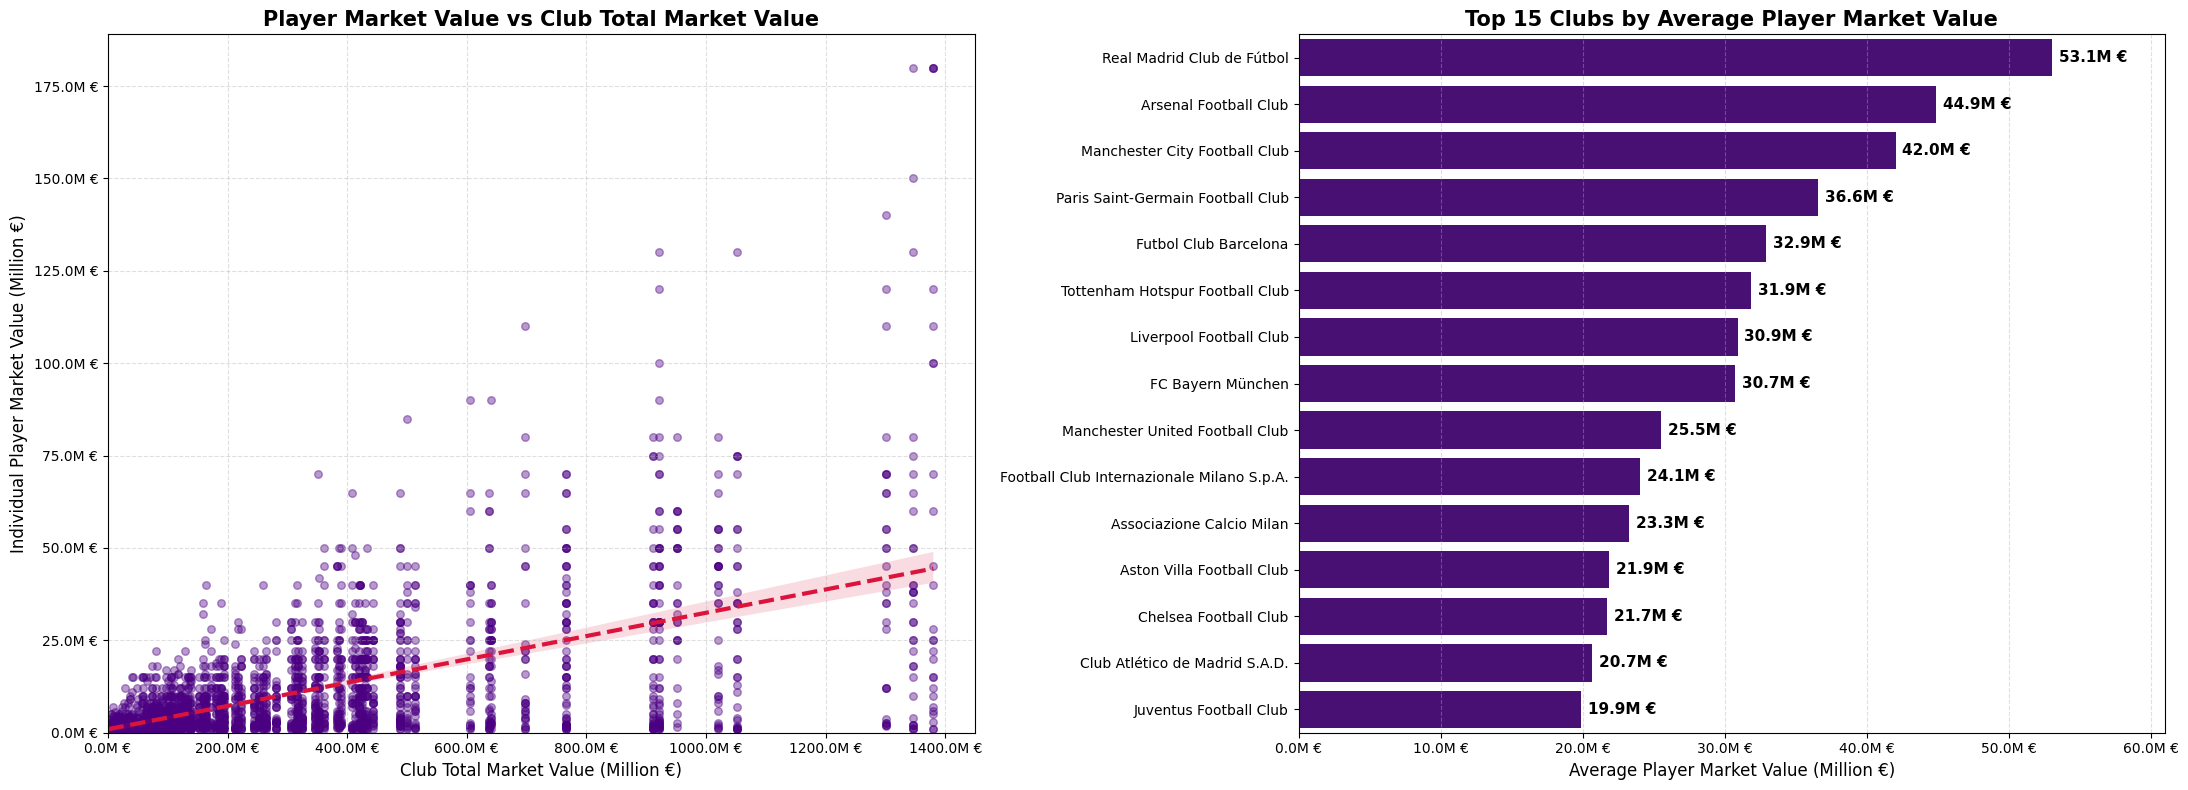

Correlation (Club Total Value vs Individual Player Value): 0.59


In [24]:
# Institutional Analysis: Examining the relationship between club financial strength and individual player valuations, identifying elite clubs by average player market value
club_stats = top_5_players.groupby('current_club_name').agg(
    club_total_value=('market_value_in_eur', 'sum'),
    club_avg_value=('market_value_in_eur', 'mean'),
    squad_size=('player_id', 'count')
).reset_index()

club_player_df = pd.merge(top_5_players, club_stats, on='current_club_name', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Plot 1: Regression analysis showing how individual player values scale with the club's total squad value
sns.regplot(
    data=club_player_df,
    x='club_total_value',
    y='market_value_in_eur',
    scatter_kws={'alpha': 0.4, 's': 30, 'color': 'indigo'},
    line_kws={'color': 'crimson', 'linewidth': 3, 'linestyle': '--'},
    ax=axes[0]
)
axes[0].xaxis.set_major_formatter(FuncFormatter(format_millions))
axes[0].yaxis.set_major_formatter(FuncFormatter(format_millions))
axes[0].set_title('Player Market Value vs Club Total Market Value', fontsize=15, weight='bold')
axes[0].set_xlabel('Club Total Market Value (Million €)', fontsize=12)
axes[0].set_ylabel('Individual Player Market Value (Million €)', fontsize=12)
axes[0].set_xlim(0, club_player_df['club_total_value'].max() * 1.05)
axes[0].set_ylim(0, club_player_df['market_value_in_eur'].max() * 1.05)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Plot 2: Identifying the top 15 most valuable squads based on average player valuation
top_15_clubs = club_stats.sort_values('club_avg_value', ascending=False).head(15)

sns.barplot(
    data=top_15_clubs,
    x='club_avg_value',
    y='current_club_name',
    color='indigo',  
    errorbar=None,
    ax=axes[1]
)
axes[1].xaxis.set_major_formatter(FuncFormatter(format_millions))
axes[1].set_title('Top 15 Clubs by Average Player Market Value', fontsize=15, weight='bold')
axes[1].set_xlabel('Average Player Market Value (Million €)', fontsize=12)
axes[1].set_ylabel('')
axes[1].set_xlim(0, top_15_clubs['club_avg_value'].max() * 1.15)
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

# Annotate bars with precise average values
for container in axes[1].containers:
    axes[1].bar_label(container, fmt=lambda x: f'{x/1e6:.1f}M €', padding=5, weight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Quantify the financial synergy between a club's total worth and its individual player values
corr_club = club_player_df['club_total_value'].corr(club_player_df['market_value_in_eur'])
print(f"Correlation (Club Total Value vs Individual Player Value): {corr_club:.2f}")